# Data Preparation Notebook

* #### This notebook prepares the Schlieren velocimetry dataset of a turbulent jet [1] for NO+DM training

* #### First, download the dataset from Zenodo. 
    * Go to link (https://zenodo.org/records/6136052).
    * Download 20210125-Run1.zip and unzip it



* #### If this link is not working, refer [1] 

* #### [1] - Settles, Gary S., and Alex Liberzon. "Schlieren and BOS velocimetry of a round turbulent helium jet in air." Optics and Lasers in Engineering 156 (2022): 107104.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import os

In [6]:
directory_path = 're_5000'

# List all files in the directory
files = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]

# print(files)

In [27]:
image_ls = []
for i in range(1000):
    filename = f"{directory_path}/{files[i]}"
    image_array = tiff.imread(filename)[::4,::4]
    image_ls.append(image_array)
    # print(image_array.shape, image_array.dtype)  # Prints the shape of the loaded array
rho = np.array(image_ls)

In [28]:
rho.shape

(1000, 128, 256)

In [29]:
np.save("rho_re_5000.npy", rho)

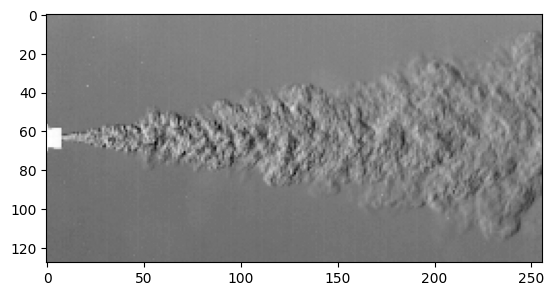

In [25]:
plt.imshow(np.fliplr(image_array), 'binary' )
plt.show()

In [31]:
np.min(image_array)

0

In [32]:
traj = np.load(f"rho_re_5000.npy").astype(np.float32)/256 #[nt, nx, ny]
traj.shape

(1000, 128, 256)

In [33]:
traj.dtype

dtype('float32')

In [35]:
traj.max()

0.99609375